## NGL vinth2p
[vinth2p documentation](https://www.pyngl.ucar.edu/Functions/Ngl.vinth2p.shtml)

In [1]:
import Ngl
import os
import xarray as xr
import numpy as np
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from xarray.coders import CFDatetimeCoder
from matplotlib.dates import DateFormatter, HourLocator, date2num, num2date

SCRATCHDIR = "/glade/derecho/scratch/nforcone"
RUNDIR = "CAM_6_4_025_20240829_SEne30_L30_400m_fadiab_lamb_isothermal_275K_Narrow/run"
FILENAME = "CAM_6_4_025_20240829_SEne30_L30_400m_fadiab_lamb_isothermal_275K_Narrow.cam.h0i.0001-01-01-01800.nc"
joined_path = os.path.join(SCRATCHDIR, RUNDIR, FILENAME)
joined_path
ds = xr.open_dataset(joined_path, decode_cf=False)
time_dt = num2date(ds["time"])

In [14]:
clevs = np.linspace(-0.008, 0.008, num=10)
clevs

array([-0.008     , -0.00622222, -0.00444444, -0.00266667, -0.00088889,
        0.00088889,  0.00266667,  0.00444444,  0.00622222,  0.008     ])

In [15]:
U850 = ds.U850
U850

<xarray.DataArray 'U850' (time: 240, lat: 257, lon: 512)> Size: 126MB
[31580160 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.3 -88.59 -87.89 ... 88.59 89.3 90.0
  * lon      (lon) float64 4kB 0.0 0.7031 1.406 2.109 ... 357.9 358.6 359.3
  * time     (time) float64 2kB 0.02083 0.04167 0.0625 ... 4.958 4.979 5.0
Attributes:
    units:         m/s
    long_name:     Zonal wind at 850 mbar pressure surface
    cell_methods:  time: point

In [16]:
ds

<xarray.Dataset> Size: 21GB
Dimensions:       (lat: 257, lon: 512, lev: 30, ilev: 31, trop_pref: 30,
                   trop_prefi: 31, time: 240, nbnd: 2, chars: 8)
Coordinates:
  * lat           (lat) float64 2kB -90.0 -89.3 -88.59 ... 88.59 89.3 90.0
  * lon           (lon) float64 4kB 0.0 0.7031 1.406 2.109 ... 357.9 358.6 359.3
  * lev           (lev) float64 240B 211.9 225.2 239.2 ... 891.4 933.7 977.6
  * ilev          (ilev) float64 248B 205.4 218.4 232.0 ... 912.2 955.3 1e+03
  * trop_pref     (trop_pref) float64 240B 211.9 225.2 239.2 ... 933.7 977.6
  * trop_prefi    (trop_prefi) float64 248B 205.4 218.4 232.0 ... 955.3 1e+03
  * time          (time) float64 2kB 0.02083 0.04167 0.0625 ... 4.958 4.979 5.0
Dimensions without coordinates: nbnd, chars
Data variables: (12/49)
    w             (lat) float64 2kB ...
    hyam          (lev) float64 240B ...
    hybm          (lev) float64 240B ...
    hyai          (ilev) float64 248B ...
    hybi          (ilev) float64 248B ...
    date          (time) int32 960B ...
    ...            ...
    Z700          (time, lat, lon) float32 126MB ...
    T             (time, lev, lat, lon) float32 4GB ...
    U             (time, lev, lat, lon) float32 4GB ...
    V             (time, lev, lat, lon) float32 4GB ...
    Z3            (time, lev, lat, lon) float32 4GB ...
    OMEGA         (time, lev, lat, lon) float32 4GB ...
Attributes:
    interp_type:       bilinear
    interp_outputgri:  equally spaced with poles
    Conventions:       CF-1.0
    source:            CAM
    case:              CAM_6_4_025_20240829_SEne30_L30_400m_fadiab_lamb_isoth...
    logname:           nforcone
    host:              dec2439
    initial_file:      /glade/u/home/cjablono/CESM_vertical_grids/cam_vcoords...
    topography_file:   bnd_topo
    model_doi_url:     not_set
    time_period_freq:  minute_30

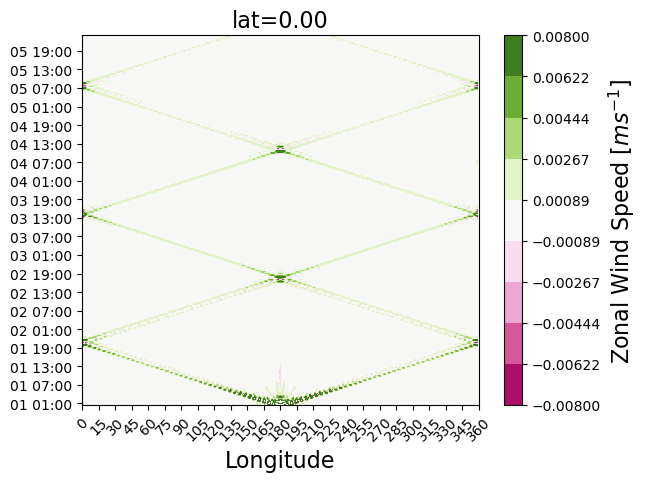

In [17]:
def Hovmoller(MyAx, field_DataArray, lat_val, MyCMAP):
    labelsize = 16
    times = field_DataArray.time
    lons = field_DataArray.lon

    field = field_DataArray[:,:, :].sel(lat=lat_val, method="nearest")

    CF = MyAx.contourf(lons, times, field, cmap=MyCMAP, levels=clevs)
    cb = plt.colorbar(CF, ax=MyAx)
    cb.set_label(r'Zonal Wind Speed [$m s^{-1}$]', size=labelsize)
    # MyAx.set_xticks([0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360])
    plt.xticks(rotation=45)
    MyAx.set_xticks(np.arange(0, 361, step=15))
    MyAx.set_xlabel("Longitude", size=labelsize)
    MyAx.yaxis.set_major_locator(HourLocator(interval=6))
    MyAx.yaxis.set_major_formatter(DateFormatter("%d %H:%M"))
    MyAx.set_title(f"lat={field.lat:.2f}", size=labelsize)


# figure and axes
plt.figure(1)
hovmoller_ax = plt.axes()

# parameters
myLevel = 850
lat_value = 0

Hovmoller(hovmoller_ax, ds.OMEGA850, lat_value, 'PiYG')
# plt.savefig('U-Hovmoller-plev-850-More-Ticks.png', dpi=250)

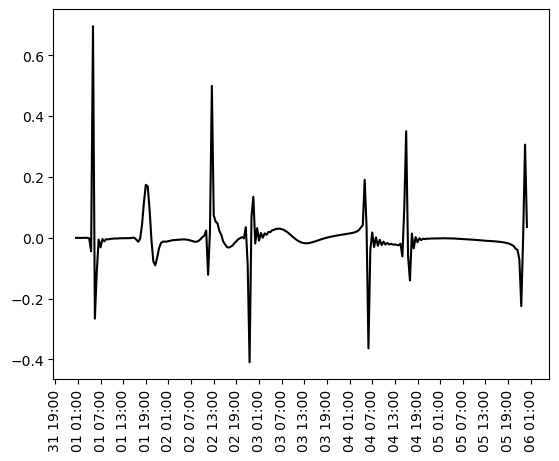

In [5]:
plt.figure(2)
tseries_ax = plt.axes()
tseries_ax.plot(U_interp_da.time, U_interp_da[:, :, :, :].sel(plev=850, lat=0, lon=225, method="nearest"), color='black')
tseries_ax.xaxis.set_major_locator(HourLocator(interval=6))
tseries_ax.xaxis.set_major_formatter(DateFormatter("%d %H:%M"))
plt.xticks(rotation=90)
plt.show()

Text(0.5, 1.0, 'Time=01 09:00')

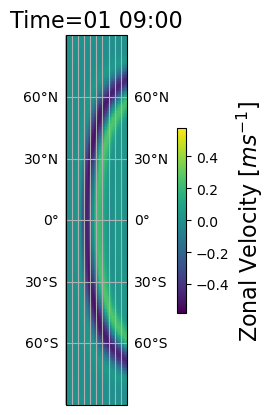

In [6]:
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LongitudeFormatter

zoomed_time_ind = 17
GeoFig = plt.figure(3)
GeoAx = plt.axes(projection=ccrs.PlateCarree())
U_CF = GeoAx.pcolormesh(U_interp_da.lon, U_interp_da.lat, U_interp_da[zoomed_time_ind, :, :, :].sel(plev=850, method="nearest"), 
                      transform=ccrs.PlateCarree())
Geo_cb = GeoFig.colorbar(U_CF, ax=GeoAx, shrink=0.5, pad=0.1)
Geo_cb.set_label(r'Zonal Velocity [$m s^{-1}$]', size=16)
GeoAx.set_extent([90, 120, -90, 90])
gl = GeoAx.gridlines(draw_labels=True)
gl.bottom_labels = False
gl.top_labels = False
gl.xlocator = mticker.FixedLocator(np.arange(90, 121, step=3))
GeoAx.set_title(f'Time={time_dt[zoomed_time_ind].strftime("%d %H:%M")}', size=16)
# plt.savefig("U-Zoomed-Spatial.png", dpi=250)

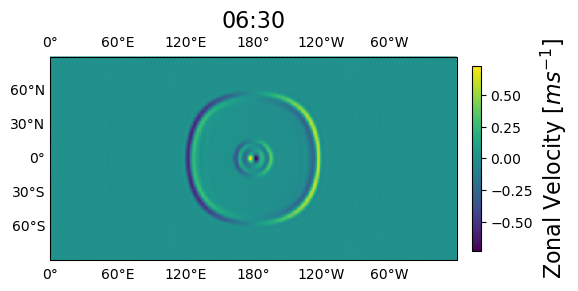

In [81]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator

Full_time_ind = 3
t2 = Full_time_ind+3
t3 = Full_time_ind+9

FullFig = plt.figure(4)
FullAx = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
Full_CF = FullAx.pcolormesh(U_interp_da.lon, U_interp_da.lat, U_interp_da[t3, :, :, :].sel(plev=850, method="nearest"), 
                           transform=ccrs.PlateCarree())
Full_cb = FullFig.colorbar(Full_CF, ax=FullAx, shrink=0.5, pad=0.03)
Full_cb.set_label(r'Zonal Velocity [$m s^{-1}$]', size=16)
Full_gl = FullAx.gridlines(draw_labels=True)
Full_gl.xlines = False
Full_gl.ylines = False
# Full_gl.bottom_labels = False
# Full_gl.top_labels = False
# gl.xlocator = mticker.FixedLocator(np.arange(90, 121, step=3))
FullAx.set_title(f'{time_dt[t3].strftime("%H:%M")}', size=16)
# plt.savefig("Full_1.png", dpi=250)
# plt.savefig("Full_2.png", dpi=250)
# plt.savefig("Full_3.png", dpi=250)